# Temperature Scaling

Effect of temperature scaling (calibration) on the **NN Combined** model's
test-set confidences. The model is calibrated with a single learned
temperature **T = 1.5783** (`best_model_calibrated.pt`); T > 1 softens the
softmax, pushing confidences **down**. Predictions carry two confidence
columns: `confidence_uncalibrated` (raw softmax max) and `confidence`
(after temperature scaling).

All temperature-related plots live here — moved out of `eval_exploration.ipynb`
to keep that notebook free of redundancy.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)
SAVE_DPI = 300

plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 110,
        "savefig.dpi": SAVE_DPI,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.axisbelow": True,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
    }
)

# Calibration colour convention: grey = before scaling, orange = after.
BEFORE_COLOR = "#94a3b8"
AFTER_COLOR = "#f97316"
NN_COLOR = "#f97316"
CORRECT_COLOR = "#10b981"
INCORRECT_COLOR = "#ef4444"
NEUTRAL_COLOR = "#6b7280"

TEMPERATURE = 1.5783  # learned scalar in best_model_calibrated.pt


def save_plot(fig, filename: str) -> Path:
    path = PLOTS_DIR / filename
    fig.savefig(path, dpi=SAVE_DPI, bbox_inches="tight")
    return path


def plot_confidence_bins(ax, confidences, correct, title):
    """Side-by-side correct vs incorrect counts for 0.1-wide confidence bins."""
    bin_edges = np.linspace(0.0, 1.0, 11)
    bin_labels = [f"{lo:.1f}–{hi:.1f}" for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]
    correct_counts, incorrect_counts = [], []
    for i, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        if i == len(bin_edges) - 2:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences >= lo) & (confidences < hi)
        correct_counts.append(int(correct[mask].sum()))
        incorrect_counts.append(int((~correct)[mask].sum()))

    x = np.arange(len(bin_labels))
    bar_w = 0.36
    ax.bar(x - bar_w / 2, correct_counts, bar_w, label="Correct",
           color=CORRECT_COLOR, edgecolor="white")
    ax.bar(x + bar_w / 2, incorrect_counts, bar_w, label="Incorrect",
           color=INCORRECT_COLOR, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=45, ha="right")
    ax.set_title(title)
    ax.set_xlabel("Confidence bin")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
    ax.legend()


def reliability(conf, correct, n_bins=15):
    """Equal-width reliability stats + expected calibration error (ECE)."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    accs, confs, counts = [], [], []
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        mask = (conf >= lo) & (conf <= hi) if i == 0 else (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            accs.append(np.nan); confs.append(np.nan); counts.append(0)
            continue
        accs.append(correct[mask].mean())
        confs.append(conf[mask].mean())
        counts.append(int(mask.sum()))
    accs, confs, counts = np.array(accs), np.array(confs), np.array(counts)
    ece = np.nansum(counts * np.abs(accs - confs)) / counts.sum()
    return edges, accs, confs, counts, ece

## Load test-set predictions

In [2]:
model_test = pd.read_csv("../benchmark/test_set/nn_combined_run/predictions.csv")
if "confidence_uncalibrated" not in model_test.columns:
    raise RuntimeError(
        "Missing confidence_uncalibrated — re-run: "
        "uv run toxfam eval model test_set --model-dir model/model_output/combined_run"
    )

nn_correct = (model_test["actual_label"] == model_test["predicted_label"]).to_numpy()
conf_before = model_test["confidence_uncalibrated"].to_numpy()
conf_after = model_test["confidence"].to_numpy()
delta = conf_after - conf_before

print(f"n = {len(model_test)}  |  accuracy = {nn_correct.mean():.4f}  |  T = {TEMPERATURE}")
print(f"mean confidence: before = {conf_before.mean():.4f}, after = {conf_after.mean():.4f}")
model_test.head()

n = 9779  |  accuracy = 0.9898  |  T = 1.5783
mean confidence: before = 0.9962, after = 0.9906


,identifier,actual_label,predicted_label,confidence,confidence_uncalibrated
0,P01502,other,other,0.990660,0.999581
1,A6YPK1,CRISP family,CRISP family,0.927131,0.984318
2,Q7ZTA0,CRISP family,CRISP family,0.999888,1.000000
3,Q8JI38,CRISP family,CRISP family,0.999870,1.000000
4,A6MFK9,CRISP family,CRISP family,0.999845,1.000000


## 1. Confidence distribution: before vs after

Temperature scaling squeezes the whole distribution toward lower confidence.
The mass piled at ≈0.99 thins out and shifts left.

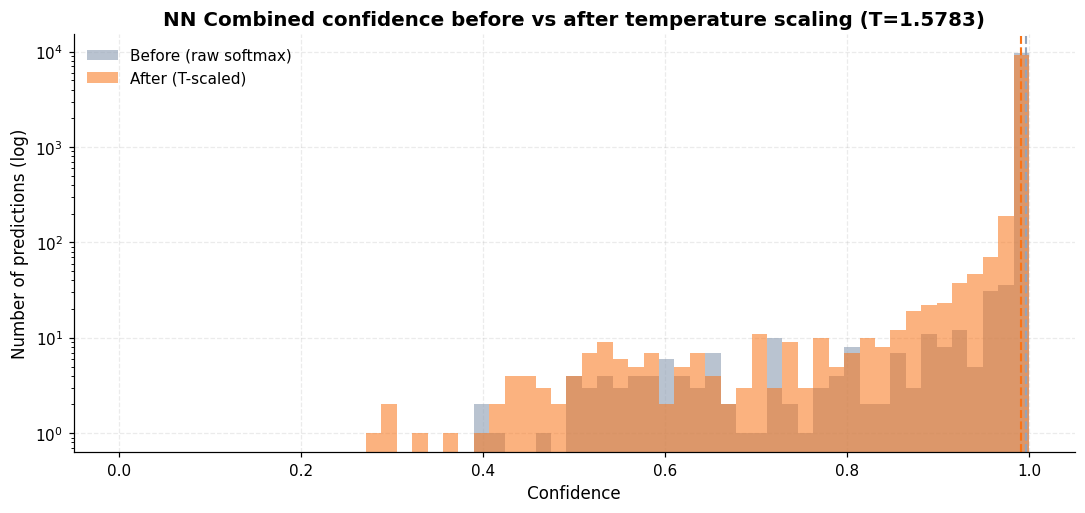

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.8))
bins = np.linspace(0, 1, 60)
ax.hist(conf_before, bins=bins, color=BEFORE_COLOR, alpha=0.65, label="Before (raw softmax)")
ax.hist(conf_after, bins=bins, color=AFTER_COLOR, alpha=0.55, label="After (T-scaled)")
ax.axvline(conf_before.mean(), color=BEFORE_COLOR, linestyle="--", lw=1.4)
ax.axvline(conf_after.mean(), color=AFTER_COLOR, linestyle="--", lw=1.4)
ax.set_yscale("log")
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of predictions (log)")
ax.set_title(f"NN Combined confidence before vs after temperature scaling (T={TEMPERATURE})")
ax.legend()
plt.tight_layout()
save_plot(fig, "temp_confidence_distribution_before_after.png")
plt.show()

## 2. Correct vs incorrect by confidence bin (before / after)

How predictions redistribute across 0.1-wide confidence bins, split by whether
they are correct. Scaling pulls the high-confidence pile leftward; most of the
movement is in the top bins.

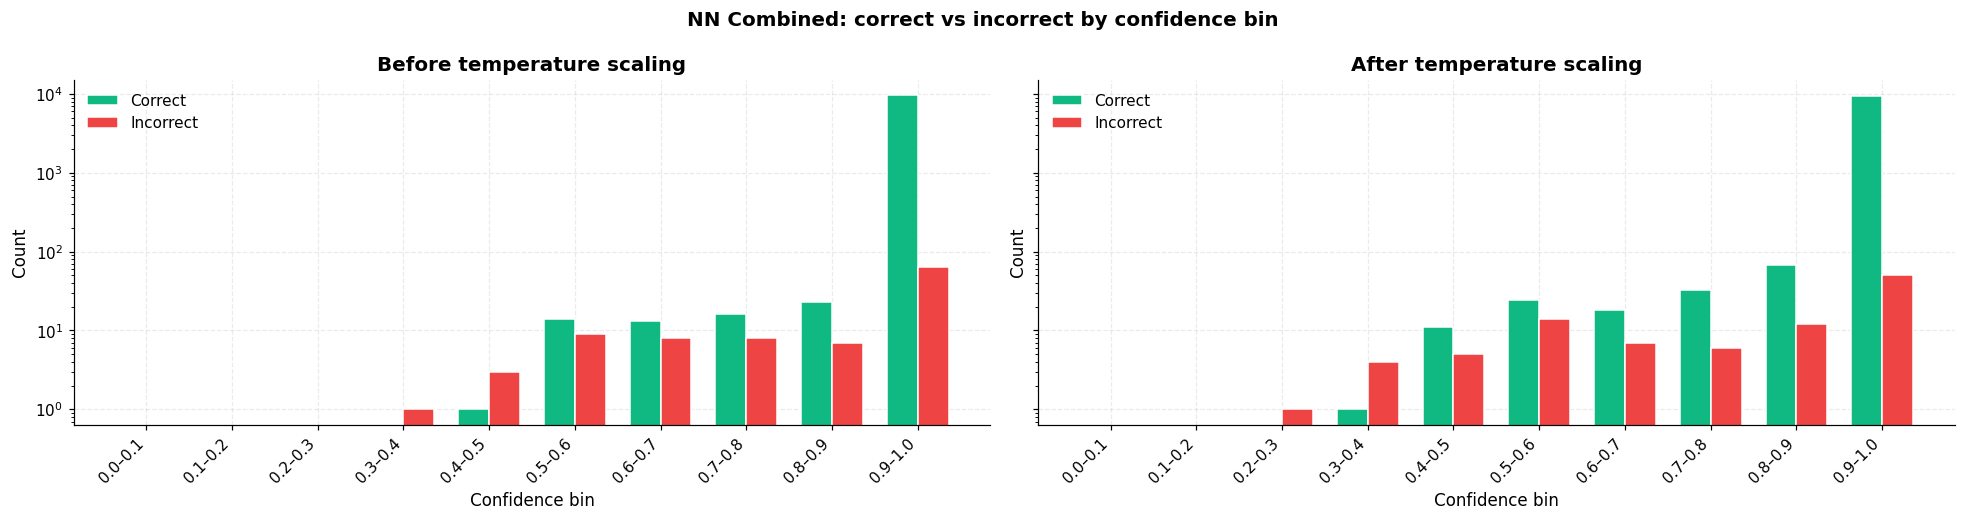

80th-percentile confidence of misclassifications (calibrated): 0.993


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4.8), sharey=True)
plot_confidence_bins(axes[0], conf_before, nn_correct, "Before temperature scaling")
plot_confidence_bins(axes[1], conf_after, nn_correct, "After temperature scaling")
fig.suptitle("NN Combined: correct vs incorrect by confidence bin",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_plot(fig, "temp_correct_vs_incorrect_bins_before_after.png")
plt.show()

nn_wrong_conf = pd.Series(conf_after[~nn_correct])
print(f"80th-percentile confidence of misclassifications (calibrated): "
      f"{nn_wrong_conf.quantile(0.8):.3f}")

## 3. Bin-count change from scaling (after − before)

Same 0.1-wide bins, but plotted as the *change* in count per bin. Positive bars
= scaling moved predictions **into** this bin, negative = **out of** it. The
top bin empties; the bins just below it fill.

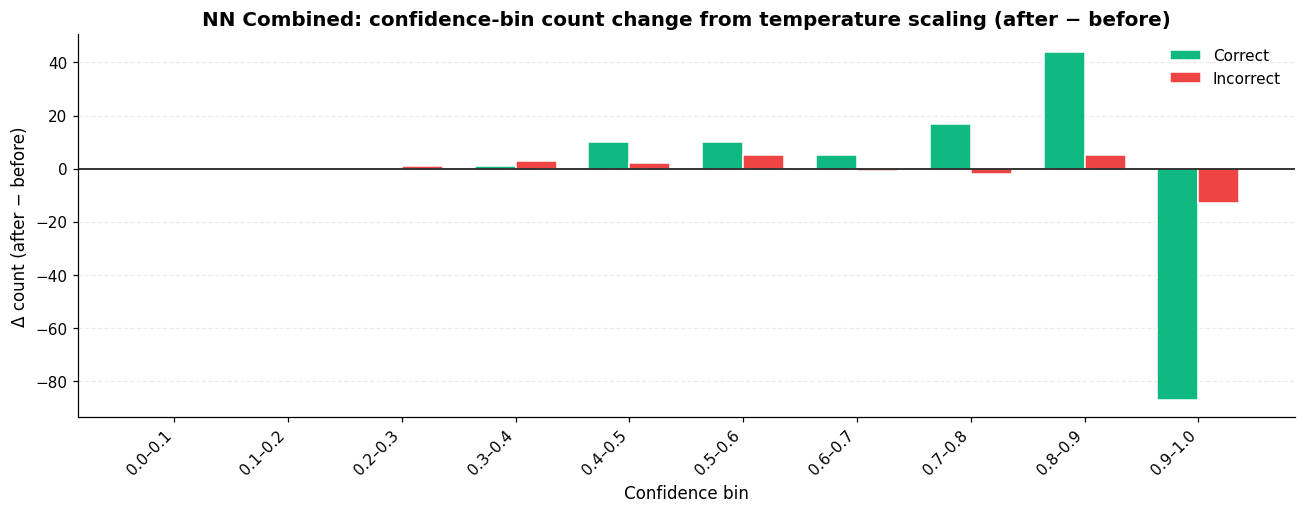

In [5]:
bin_edges = np.linspace(0.0, 1.0, 11)
bin_labels = [f"{lo:.1f}–{hi:.1f}" for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]


def _bin_counts(confidences, correct):
    conf = np.asarray(confidences)
    cc, ic = [], []
    for i, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        mask = (conf >= lo) & (conf <= hi) if i == len(bin_edges) - 2 else (conf >= lo) & (conf < hi)
        cc.append(int(correct[mask].sum()))
        ic.append(int((~correct)[mask].sum()))
    return np.array(cc), np.array(ic)


before_correct, before_incorrect = _bin_counts(conf_before, nn_correct)
after_correct, after_incorrect = _bin_counts(conf_after, nn_correct)
delta_correct = after_correct - before_correct
delta_incorrect = after_incorrect - before_incorrect

x = np.arange(len(bin_labels))
bar_w = 0.36
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(x - bar_w / 2, delta_correct, bar_w, label="Correct", color=CORRECT_COLOR, edgecolor="white")
ax.bar(x + bar_w / 2, delta_incorrect, bar_w, label="Incorrect", color=INCORRECT_COLOR, edgecolor="white")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")
ax.set_title("NN Combined: confidence-bin count change from temperature scaling (after − before)")
ax.set_xlabel("Confidence bin")
ax.set_ylabel("Δ count (after − before)")
ax.grid(axis="x", visible=False)
ax.legend()
plt.tight_layout()
save_plot(fig, "temp_bin_count_delta.png")
plt.show()

## 4. Per-prediction confidence shift (density)

Bin-free view: Δ = calibrated − uncalibrated confidence for **each** prediction,
as a fine density histogram split by correct vs incorrect. This is the most
revealing view — **incorrect predictions are pulled down far harder** than
correct ones (their median drop is ~60× larger), which is exactly what good
calibration should do: it removes confidence preferentially from the predictions
that were wrong.

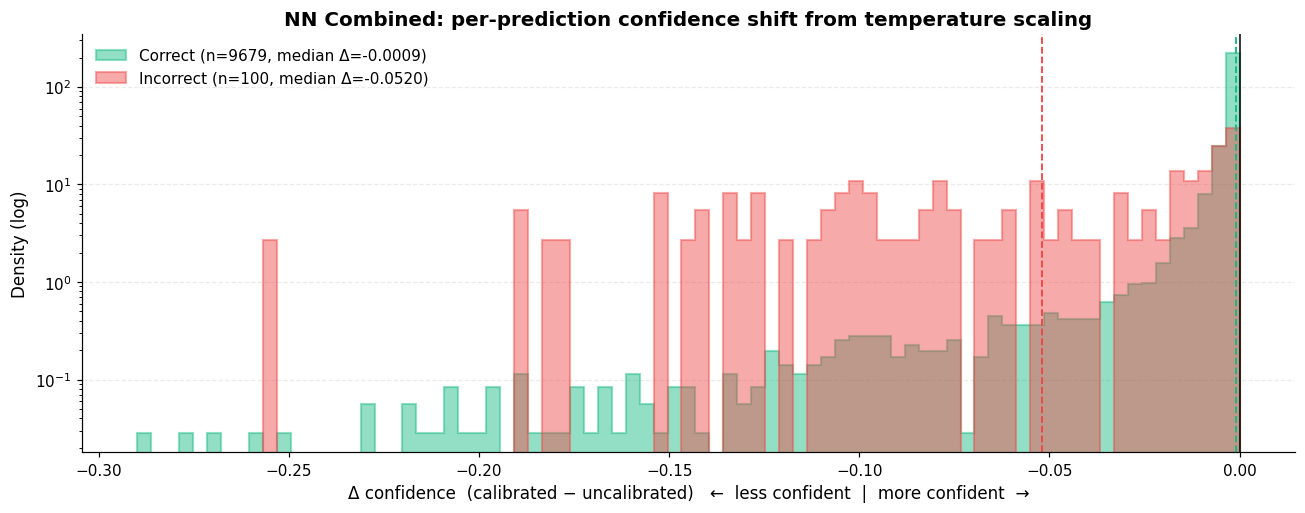

Mean Δ: correct=-0.0050, incorrect=-0.0626
Fraction pushed down (Δ<0): correct=0.999, incorrect=1.000


In [6]:
delta_correct_v = delta[nn_correct]
delta_incorrect_v = delta[~nn_correct]

lo, hi = delta.min(), delta.max()
bins = np.linspace(lo, hi, 80)

fig, ax = plt.subplots(figsize=(12, 4.8))
for d, color, label in [
    (delta_correct_v, CORRECT_COLOR, "Correct"),
    (delta_incorrect_v, INCORRECT_COLOR, "Incorrect"),
]:
    ax.hist(d, bins=bins, density=True, histtype="stepfilled", color=color,
            alpha=0.45, edgecolor=color, linewidth=1.4,
            label=f"{label} (n={len(d)}, median Δ={np.median(d):+.4f})")
    ax.axvline(np.median(d), color=color, linestyle="--", linewidth=1.2)

ax.axvline(0, color="black", linewidth=1)
ax.set_yscale("log")
ax.set_title("NN Combined: per-prediction confidence shift from temperature scaling")
ax.set_xlabel("Δ confidence  (calibrated − uncalibrated)   ←  less confident  |  more confident  →")
ax.set_ylabel("Density (log)")
ax.grid(axis="x", visible=False)
ax.legend()
plt.tight_layout()
save_plot(fig, "temp_per_prediction_shift_density.png")
plt.show()

print(f"Mean Δ: correct={delta_correct_v.mean():+.4f}, incorrect={delta_incorrect_v.mean():+.4f}")
print(f"Fraction pushed down (Δ<0): correct={(delta_correct_v < 0).mean():.3f}, "
      f"incorrect={(delta_incorrect_v < 0).mean():.3f}")

## 5. Where the shift happens: Δ vs original confidence

The shift isn't uniform. Plotting Δ against the *uncalibrated* confidence shows
a deterministic-looking band: predictions already near 1.0 barely move, while
mid-confidence predictions drop the most. The vertical spread at a given x comes
from the rest of the softmax logit vector (the shift depends on all logits, not
just the max).

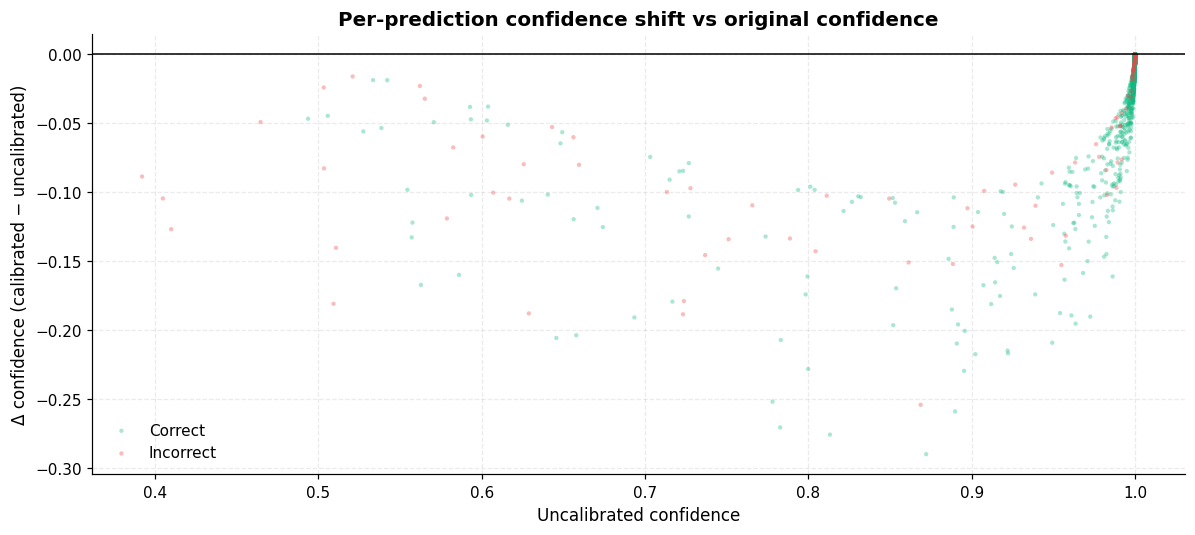

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
for m, color, label in [(nn_correct, CORRECT_COLOR, "Correct"), (~nn_correct, INCORRECT_COLOR, "Incorrect")]:
    ax.scatter(conf_before[m], delta[m], s=8, alpha=0.35, color=color, edgecolor="none", label=label)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Uncalibrated confidence")
ax.set_ylabel("Δ confidence (calibrated − uncalibrated)")
ax.set_title("Per-prediction confidence shift vs original confidence")
ax.legend(loc="lower left")
plt.tight_layout()
save_plot(fig, "temp_shift_vs_original_confidence.png")
plt.show()

## 6. Reliability diagrams + ECE (before / after)

Calibration quality: a perfectly calibrated model sits on the diagonal
(confidence = accuracy). Temperature scaling roughly **halves the expected
calibration error**. The lower panel shows where the predictions actually lie
— almost everything is in the top confidence bins, so the headline ECE is
dominated by the high-confidence region.

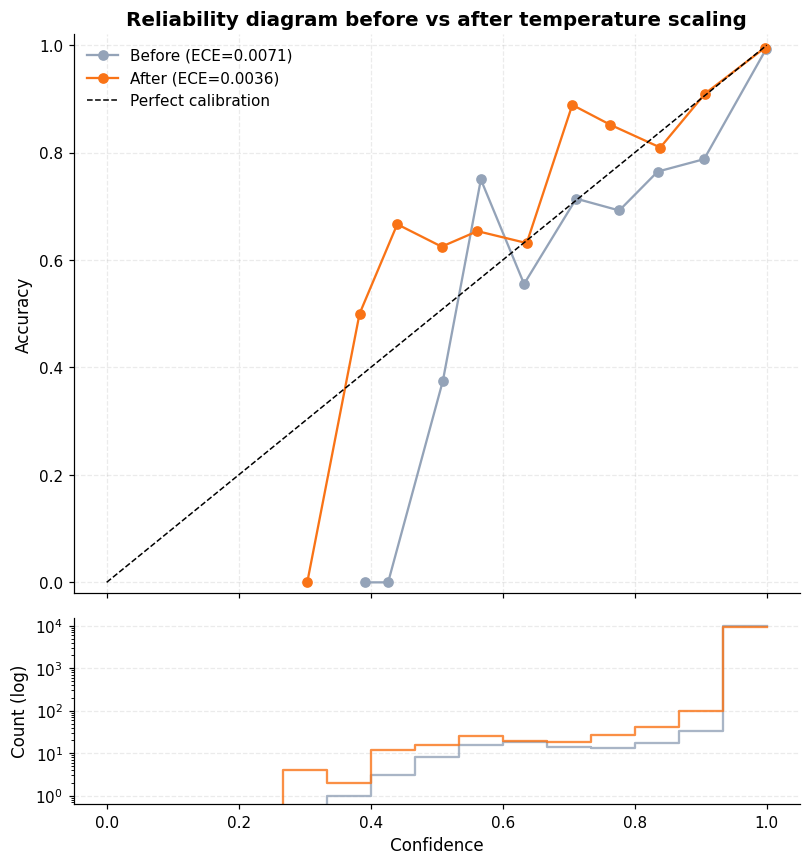

In [8]:
fig, (ax, axc) = plt.subplots(
    2, 1, figsize=(7.5, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
edges = np.linspace(0, 1, 16)
for conf, color, lab in [(conf_before, BEFORE_COLOR, "Before"), (conf_after, AFTER_COLOR, "After")]:
    _, accs, confs, counts, ece = reliability(conf, nn_correct, n_bins=15)
    ax.plot(confs, accs, marker="o", color=color, label=f"{lab} (ECE={ece:.4f})")
    axc.step(edges, np.append(counts, counts[-1]), where="post", color=color, alpha=0.8)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.set_ylabel("Accuracy")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Reliability diagram before vs after temperature scaling")
ax.legend(loc="upper left")
axc.set_yscale("log")
axc.set_ylabel("Count (log)")
axc.set_xlabel("Confidence")
axc.grid(axis="x", visible=False)
plt.tight_layout()
save_plot(fig, "temp_reliability_diagram.png")
plt.show()

### 6b. Reliability zoomed to the high-confidence region

Since nearly all predictions sit above 0.9, here is the same diagram restricted
to [0.9, 1.0] with finer bins — this is where calibration actually matters for
this model.

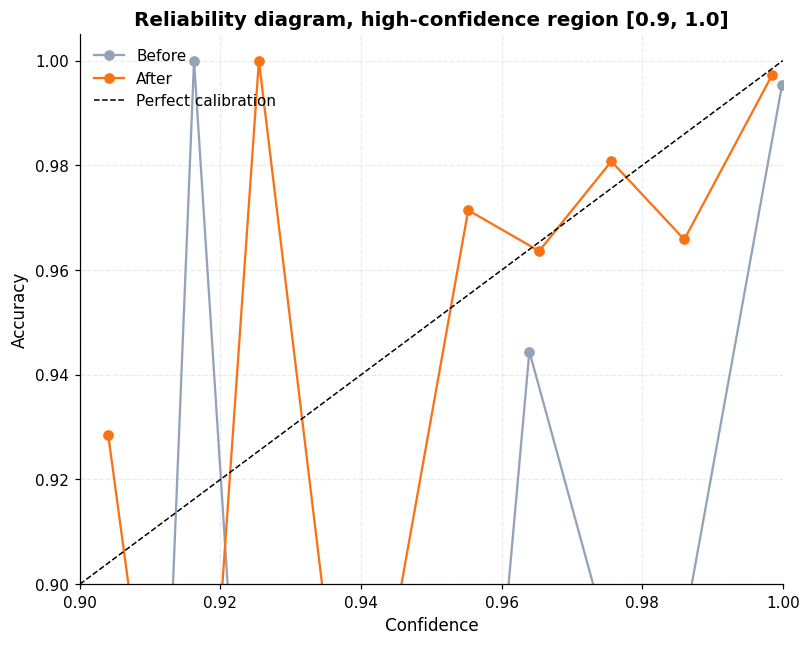

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 6))
hi_edges = np.linspace(0.9, 1.0, 11)
hi_centers = (hi_edges[:-1] + hi_edges[1:]) / 2
for conf, color, lab in [(conf_before, BEFORE_COLOR, "Before"), (conf_after, AFTER_COLOR, "After")]:
    accs, confs = [], []
    for i, (lo, hi) in enumerate(zip(hi_edges[:-1], hi_edges[1:])):
        mask = (conf >= lo) & (conf <= hi) if i == 0 else (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            accs.append(np.nan); confs.append(np.nan); continue
        accs.append(nn_correct[mask].mean()); confs.append(conf[mask].mean())
    ax.plot(confs, accs, marker="o", color=color, label=lab)
ax.plot([0.9, 1.0], [0.9, 1.0], "k--", lw=1, label="Perfect calibration")
ax.set_xlim(0.9, 1.0)
ax.set_ylim(0.9, 1.005)
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Reliability diagram, high-confidence region [0.9, 1.0]")
ax.legend(loc="upper left")
plt.tight_layout()
save_plot(fig, "temp_reliability_diagram_zoom.png")
plt.show()

## 7. Sorted confidence & ECDF

Two complementary cumulative views of the squeeze. Left: confidences sorted by
rank — the after-curve sits below the before-curve everywhere (every prediction
loses confidence, monotonically). Right: ECDF — the after-curve is shifted left,
so a larger fraction of predictions now fall below any given confidence.

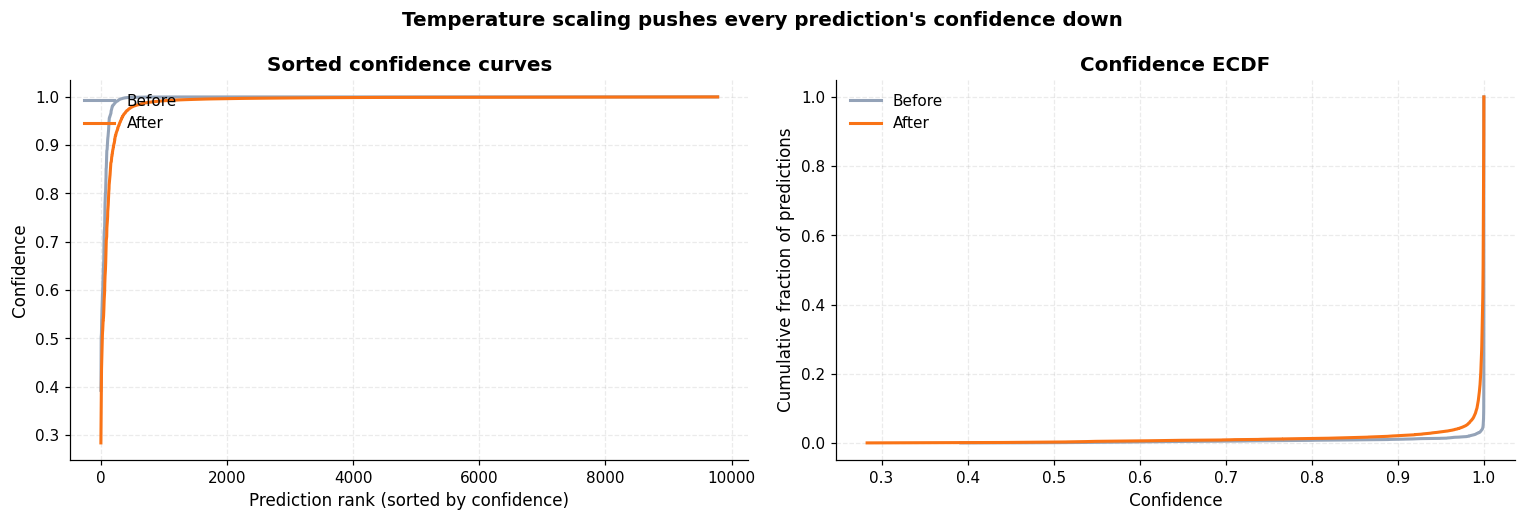

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

ax1.plot(np.sort(conf_before), color=BEFORE_COLOR, lw=2, label="Before")
ax1.plot(np.sort(conf_after), color=AFTER_COLOR, lw=2, label="After")
ax1.set_xlabel("Prediction rank (sorted by confidence)")
ax1.set_ylabel("Confidence")
ax1.set_title("Sorted confidence curves")
ax1.legend(loc="upper left")

for conf, color, lab in [(conf_before, BEFORE_COLOR, "Before"), (conf_after, AFTER_COLOR, "After")]:
    xs = np.sort(conf)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax2.plot(xs, ys, color=color, lw=2, label=lab)
ax2.set_xlabel("Confidence")
ax2.set_ylabel("Cumulative fraction of predictions")
ax2.set_title("Confidence ECDF")
ax2.legend(loc="upper left")

fig.suptitle("Temperature scaling pushes every prediction's confidence down",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_plot(fig, "temp_sorted_and_ecdf.png")
plt.show()

## 8. Summary table

In [11]:
_, _, _, _, ece_before = reliability(conf_before, nn_correct, n_bins=15)
_, _, _, _, ece_after = reliability(conf_after, nn_correct, n_bins=15)

summary = pd.DataFrame(
    {
        "before": [conf_before.mean(), np.median(conf_before), ece_before,
                   np.median(delta[nn_correct]), np.median(delta[~nn_correct])],
        "after": [conf_after.mean(), np.median(conf_after), ece_after, np.nan, np.nan],
    },
    index=["mean confidence", "median confidence", "ECE (15 bins)",
           "median Δ (correct)", "median Δ (incorrect)"],
)
print(f"Temperature T = {TEMPERATURE}")
print(f"ECE reduced {ece_before:.4f} → {ece_after:.4f} "
      f"({100 * (1 - ece_after / ece_before):.0f}% lower)")
summary

Temperature T = 1.5783
ECE reduced 0.0071 → 0.0036 (50% lower)


,before,after
mean confidence,0.996234,0.990625
median confidence,0.999996,0.999102
ECE (15 bins),0.007068,0.003561
median Δ (correct),-0.000878,NaN
median Δ (incorrect),-0.052030,NaN
